## Prediction Model
- Prediction model fitting and model evaluation
- Model I: Logistic regression to predict `ask_return_direction`
- Model II: Ridge regression to predict `ask_return_log_std`

### Data Loading

In [2]:
### Data Loading
from execution_timing.data_loading import read_raw_data, truncate_depth, holdout_split

data_mbp10 = read_raw_data('data_raw/nvda_mbp-10_2026-07-01.parquet')
data_depth = 3
data = truncate_depth(data_mbp10, data_depth)
data, data_holdout = holdout_split(data, holdout_mins=120, purge_ticks=0)
print(f"Train data shape: {data.shape}")
print(f"Holdout data shape: {data_holdout.shape}")

Train data shape: (1797483, 12)
Holdout data shape: (621973, 12)


In [3]:
## Generate factors and labels
from execution_timing.feature_engineering import load_factors_and_labels

factor_hyperparameters = {
    'obi_weighted': {'level_weights': (80, 20, 0)},
    'spread': {},
    'spread_deviation': {'look_back_ticks': 300},
    'ask_px_momentum': {'lag_ticks': 50},
    'bid_px_momentum': {'lag_ticks': 50},
    'vwap_mid_deviation_ask': {'look_back_ticks': 30,
                               'level_weights': (100, 0, 0)},
    'vwap_mid_deviation_bid': {'look_back_ticks': 30,
                               'level_weights': (100, 0, 0)},
}

look_forward_ticks = 100
label_hyperparameters = { # only use 2 labels
    "ask_return_direction": {"look_forward_ticks": look_forward_ticks},
    # "ask_return_log_std": {"look_forward_ticks": look_forward_ticks},
}

factors, labels = load_factors_and_labels(data,
                                          data_depth=data_depth,
                                          factor_hyperparameters=factor_hyperparameters,
                                          label_hyperparameters=label_hyperparameters,
                                          dropna=True)
print(f"Factors shape: {factors.shape}")
print(f"Labels shape: {labels.shape}")

# Justification:
# 1. Downsampling helps remove overlapping labels, reducing autocorrelation during regression
# 2. Per-second data is still large enough for model fitting; downsampling would not affect model training and prediction
# factors = factors.resample(rule='0.5s').first().ffill()
# labels = labels.resample(rule='0.5s').first().ffill()
# print(f"Factors downsampled shape: {factors.shape}")
# print(f"Labels downsampled shape: {labels.shape}")

Dropped 400 rows with NaN values
Factors shape: (1797083, 7)
Labels shape: (1797083, 1)


### Prediction Model Fitting I
- Fits `ask_return_direction` using logistic regression

In [4]:
import pandas as pd
import sklearn
from execution_timing.prediction_model import PredictionModel
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

label_name = 'ask_return_direction'
X_train = factors.resample(rule='0.5s').first().ffill()
y_train = labels[label_name].resample(rule='0.5s').first().ffill()

scaler = StandardScaler()
model = LogisticRegression(l1_ratio=0, # penalty = l1_ratio * L1 + (1 − l1_ratio) * L2; l1_ratio=0 -> Ridge
                           C=1, # C=1/alpha where alpha is the coefficient for penalty term; bigger alpha mode penalty
                           max_iter=1000,
                           # class_weight='balanced', # reweights each sample inversely to its class frequency
                           )
prediction_model = PredictionModel(model, scaler)
prediction_model.train(X_train, y_train)

# in-sample prediction
y_pred = prediction_model.predict_proba(X_train)

### In-sample Evaluation I

- **ROC / AUC**: probability that a random up-tick gets a higher predicted prob than a random down-tick (0.5 = noise). The ROC plot shows the model against the no-skill baseline: a constant prediction has no ranking information, so its curve is the diagonal and its AUC is exactly 0.5.
- **Quantile table**: sort by predicted prob, split into equal-count buckets. `realized_up_rate` should rise monotonically (ranking works); `mean_pred_prob ≈ realized_up_rate` per row means the probabilities are calibrated — important because the trading signal consumes the probability itself.
- **Coefficient plot**: factors are standardized, so each bar is the log-odds change per 1 standard deviation of the factor and magnitudes are comparable across factors.
- **Predicted prob by realized class**: overlaid density histograms of the predicted prob for ticks that realized up vs down.

Note: in-sample calibration is flattering by construction for logistic regression; judge calibration for real on the holdout.

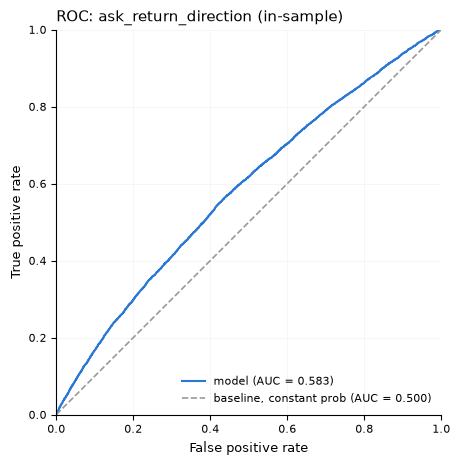

In [5]:
from execution_timing.visualization import plot_roc

# ROC: model vs no-skill baseline.
# The baseline predicts the base rate for every tick
plot_roc(y_true=y_train,
         y_pred_prob=y_pred,
         title='ROC: ask_return_direction (in-sample)')

In [6]:
from execution_timing.visualization import display_quantile_table

display_quantile_table(y_pred=y_pred, y_true=y_train).round(4)

,mean_y_pred,mean_y_true,size
quantile,,,
0,0.2813,0.2956,2520.0
1,0.3208,0.3243,2519.0
2,0.3430,0.3287,2519.0
3,0.3617,0.3623,2520.0
4,0.3792,0.3585,2519.0
5,0.3971,0.4109,2519.0
6,0.4162,0.4139,2520.0
7,0.4383,0.4331,2519.0
8,0.4679,0.4780,2519.0


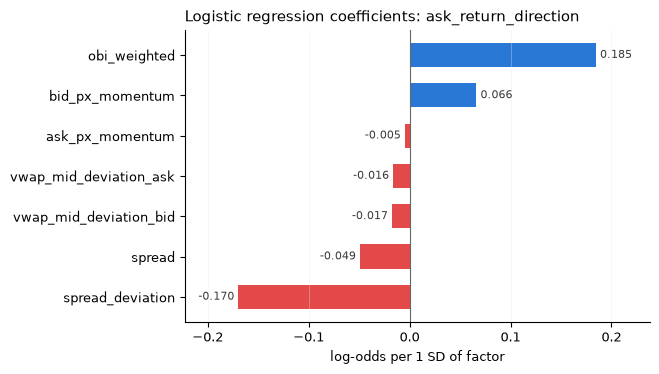

In [7]:
from execution_timing.visualization import plot_coefficients

# Caveat: collinear pairs (bid/ask momentum, the two vwap deviations) can
# split weight arbitrarily between them -- read those bars jointly.
coefs = prediction_model.get_model_coeff()
plot_coefficients(coefs,
                  title='Logistic regression coefficients: ask_return_direction',
                  unit='log-odds per 1 SD of factor')

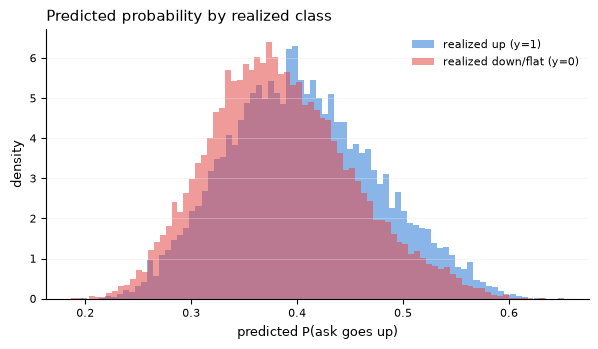

In [8]:
from execution_timing.visualization import plot_prob_by_class

# The horizontal separation between the two shapes is what AUC measures;
# expect heavy overlap with a visible shift at AUC ~0.59.
plot_prob_by_class(y_true=y_train, y_pred_prob=y_pred)

### Prediction Model Fitting II
- Fits `ask_return_log_std` using linear gression

In [9]:
## Generate factors and labels
factor_hyperparameters = {
    'obi_weighted': {'level_weights': (34, 33, 33)},
    'spread': {},
    'spread_deviation': {'look_back_ticks': 600},
    'ask_px_momentum': {'lag_ticks': 600},
    'bid_px_momentum': {'lag_ticks': 600},
    'vwap_mid_deviation_ask': {'look_back_ticks': 30,
                               'level_weights': (100, 0, 0)},
    'vwap_mid_deviation_bid': {'look_back_ticks': 30,
                               'level_weights': (100, 0, 0)},
}

look_forward_ticks = 100
label_hyperparameters = { # only use 2 labels
    # "ask_return_direction": {"look_forward_ticks": look_forward_ticks},
    "ask_return_log_std": {"look_forward_ticks": look_forward_ticks},
}

factors, labels = load_factors_and_labels(data,
                                          data_depth=data_depth,
                                          factor_hyperparameters=factor_hyperparameters,
                                          label_hyperparameters=label_hyperparameters,
                                          dropna=True)
print(f"Factors shape: {factors.shape}")
print(f"Labels shape: {labels.shape}")


Dropped 700 rows with NaN values
Factors shape: (1796783, 7)
Labels shape: (1796783, 1)


In [10]:
from sklearn.linear_model import Ridge
import numpy as np

label_name = 'ask_return_log_std'
X_train = factors.resample(rule='0.5s').first().ffill()
y_train = labels[label_name].resample(rule='0.5s').first().ffill()

scaler = StandardScaler()
model = Ridge(alpha=1, # larger alpha -> more penalty
              )
prediction_model = PredictionModel(model, scaler)
prediction_model.train(X_train, y_train)

# in-sample prediction
y_pred = prediction_model.predict(X_train)

### In-Sample Evaluation II

- **Coefficient plot**: factors are standardized, so each bar is the change in predicted log-std per 1 standard deviation of the factor; magnitudes are comparable across factors.
- **Quantile table**: sort by predicted log-std, split into equal-count buckets. `mean_y_true` rising monotonically means the vol ranking works; `mean_y_pred ≈ mean_y_true` per row means the levels are calibrated.
- **Persistence baseline**: volatility is strongly autocorrelated, so the honest benchmark is the naive forecast "next window's vol = last window's vol" (the label shifted forward 100 ticks). Result: the model beats the baseline on both rank correlation (Spearman IC 0.199 vs 0.110) and linear correlation (Pearson IC 0.266 vs 0.103) — the factors add real information beyond recent vol.
- **Vol through the day**: predicted vs realized log-std as time series (1-min means) with price context. The model should track the intraday vol pattern.

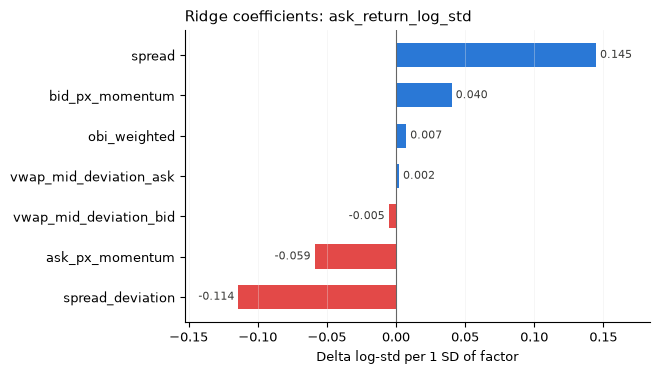

In [11]:
coefs = prediction_model.get_model_coeff()
plot_coefficients(coefs,
                  title='Ridge coefficients: ask_return_log_std',
                  unit='Delta log-std per 1 SD of factor')

In [12]:
quantile_table = display_quantile_table(y_pred=y_pred, y_true=y_train)
display(quantile_table.round(4))

,mean_y_pred,mean_y_true,size
quantile,,,
0,-10.5834,-10.5996,2520.0
1,-10.5431,-10.5520,2519.0
2,-10.5215,-10.5068,2519.0
3,-10.5043,-10.4688,2519.0
4,-10.4885,-10.4488,2519.0
5,-10.4739,-10.4975,2519.0
6,-10.4583,-10.4679,2519.0
7,-10.4410,-10.4618,2519.0
8,-10.4195,-10.4418,2519.0


In [13]:
from scipy.stats import spearmanr

# Does the model beat the naive baseline?
# Naive baseline: use trailing windows' log std as the predicted future log std

# Shifting label forward by 100 ticks gives the trailing window [t-99, t]:
# fully observed at t, no lookahead.
baseline = labels[label_name].shift(100).resample('0.5s').first()

# align both forecasts and realized vol on the same 0.5s timestamps
df_ic = pd.DataFrame({'model': y_pred,
                      'baseline': baseline,
                      'realized': y_train}).dropna()

# Spearman IC: rank correlation with realized vol
# Pearson IC: linear correlation in log-std units
print('Model Spearman IC:    ', spearmanr(df_ic['model'], df_ic['realized']).statistic.round(3))
print('Baseline Spearman IC: ', spearmanr(df_ic['baseline'], df_ic['realized']).statistic.round(3))
print('Model Pearson IC:     ', df_ic['model'].corr(df_ic['realized']).round(3))
print('Baseline Pearson IC:  ', df_ic['baseline'].corr(df_ic['realized']).round(3))

Model Spearman IC:     0.102
Baseline Spearman IC:  0.046
Model Pearson IC:      0.062
Baseline Pearson IC:   0.009


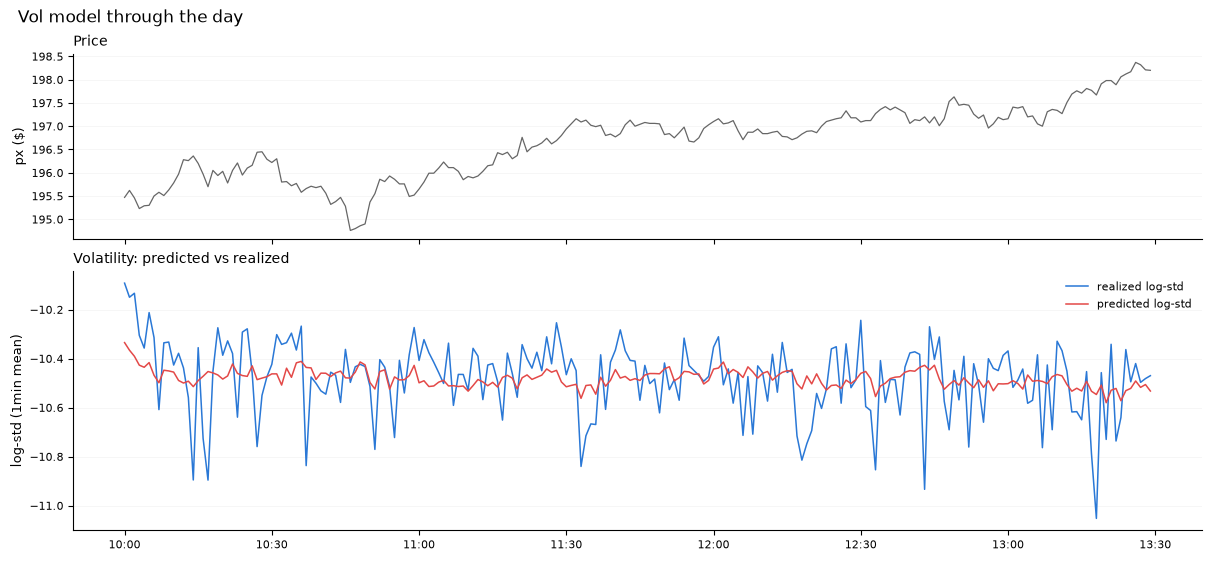

In [14]:
from execution_timing.visualization import plot_volatility_model
plot_volatility_model(y_pred=y_pred, y_true=y_train, price_series=data['ask_px_00'],resample_freq='1min')